In [147]:
import pandas as pd

# Load all 3 datasets with encoding fix
df_main = pd.read_csv('data/matches/matches.csv', encoding='utf-8')
df_2025 = pd.read_csv('data/ipl_2025/matches.csv', encoding='utf-8')
df_2026 = pd.read_csv('data/ipl_2026/IPL_2026_Data.csv', encoding='latin1')

# Verify all loaded
print("2008-2024 shape:", df_main.shape)
print("2025 shape     :", df_2025.shape)
print("2026 shape     :", df_2026.shape)

2008-2024 shape: (1095, 20)
2025 shape     : (74, 22)
2026 shape     : (74, 27)


In [148]:
# Clean 2008-2024
cols_main = ['season', 'team1', 'team2', 'toss_winner',
             'toss_decision', 'venue', 'winner', 'match_type']

df_main_clean = df_main[cols_main].copy()
df_main_clean.columns = ['season', 'team1', 'team2', 'toss_winner',
                          'toss_decision', 'venue', 'winner', 'match_type']

# Fix season column - convert all to string first then to int
def fix_season(season):
    season = str(season).strip()
    if season == '2007/08':
        return 2008
    elif season == '2009/10':
        return 2010
    elif season == '2020/21':
        return 2020
    else:
        return int(season[:4])

df_main_clean['season'] = df_main_clean['season'].apply(fix_season)


# Clean 2025
cols_2025 = ['date', 'team1', 'team2', 'toss_winner',
             'toss_decision', 'venue', 'match_winner', 'stage']

df_2025_clean = df_2025[cols_2025].copy()
df_2025_clean.columns = ['season', 'team1', 'team2', 'toss_winner',
                          'toss_decision', 'venue', 'winner', 'match_type']
df_2025_clean['season'] = 2025

# Clean 2026
cols_2026 = ['Match_No', 'Team1', 'Team2', 'Toss_winner',
             'Toss_winner_decision', 'Venue', 'Match_winner', 'Match_stage']

df_2026_clean = df_2026[cols_2026].copy()
df_2026_clean.columns = ['season', 'team1', 'team2', 'toss_winner',
                          'toss_decision', 'venue', 'winner', 'match_type']
df_2026_clean['season'] = 2026


# Merge all 3
df_all = pd.concat([df_main_clean, df_2025_clean, df_2026_clean],
                    ignore_index=True)


# Verify
print("\n=== MERGED DATASET ===")
print(f"Total matches : {len(df_all)}")
print(f"Seasons       : {sorted(df_all['season'].unique())}")
print(f"Missing values: {df_all.isnull().sum().sum()}")
print(f"\nFirst 3 rows:")
print(df_all.head(3))
print(f"\nLast 3 rows:")
print(df_all.tail(3))


=== MERGED DATASET ===
Total matches : 1243
Seasons       : [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Missing values: 9

First 3 rows:
   season                        team1                  team2  \
0    2008  Royal Challengers Bangalore  Kolkata Knight Riders   
1    2008              Kings XI Punjab    Chennai Super Kings   
2    2008             Delhi Daredevils       Rajasthan Royals   

                   toss_winner toss_decision  \
0  Royal Challengers Bangalore         field   
1          Chennai Super Kings           bat   
2             Rajasthan Royals           bat   

                                        venue                 winner  \
0                       M Chinnaswamy Stadium  Kolkata Knight Riders   
1  Punjab Cricket Association Stadium, Mohali    Chennai Super Kings   
2                            Feroz Shah Kotla       Delhi Daredevils   

  match_type  
0     League  
1     League  
2  

In [149]:
# Drop rows where winner is missing
df_all = df_all.dropna(subset=['winner'])

# Also drop row where toss_winner is missing
df_all = df_all.dropna(subset=['toss_winner'])

# Reset index after dropping
df_all = df_all.reset_index(drop=True)

# Fix toss_decision - standardize to lowercase
df_all['toss_decision'] = df_all['toss_decision'].str.lower().str.strip()

# remove Winner = No Result rows
df_all = df_all[df_all['winner'] != 'No Result']
df_all = df_all.reset_index(drop=True)

# Verify
print(f"Total matches after cleaning : {len(df_all)}")
print(f"Missing values remaining     : {df_all.isnull().sum().sum()}")

Total matches after cleaning : 1234
Missing values remaining     : 0


In [150]:
# Feature Engineering
# Standardize team names — RCB was called "Royal Challengers Bangalore" and "Royal Challengers Bengaluru" in different seasons — model sees these as 2 different teams!

team_name_map = {
    # Short names → Full names
    'CSK'  : 'Chennai Super Kings',
    'DC'   : 'Delhi Capitals',
    'KKR'  : 'Kolkata Knight Riders',
    'MI'   : 'Mumbai Indians',
    'PBKS' : 'Punjab Kings',
    'RCB'  : 'Royal Challengers Bengaluru',
    'RR'   : 'Rajasthan Royals',
    'LSG'  : 'Lucknow Super Giants',
    'GT'   : 'Gujarat Titans',
    'SRH'  : 'Sunrisers Hyderabad',

    # Old names → Current names
    'Delhi Daredevils'              : 'Delhi Capitals',
    'Kings XI Punjab'               : 'Punjab Kings',
    'Royal Challengers Bangalore'   : 'Royal Challengers Bengaluru',
    'Deccan Chargers'               : 'Sunrisers Hyderabad',

    # Typo fix
    'Rising Pune Supergiant'        : 'Rising Pune Supergiants',
}

# Apply to all team columns
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    df_all[col] = df_all[col].replace(team_name_map)

# Add home ground feature
home_keywords = {
    'Mumbai Indians': [
        'Wankhede', 'DY Patil'
    ],
    'Chennai Super Kings': [
        'Chidambaram', 'Chepauk'
    ],
    'Royal Challengers Bengaluru': [
        'Chinnaswamy'
    ],
    'Kolkata Knight Riders': [
        'Eden'
    ],
    'Delhi Capitals': [
        'Arun Jaitley', 'Feroz Shah Kotla'
    ],
    'Sunrisers Hyderabad': [
        'Rajiv Gandhi', 'Uppal'
    ],
    'Rajasthan Royals': [
        'Sawai Mansingh'
    ],
    'Punjab Kings': [
        'PCA', 'Bindra', 'Mullanpur', 'Maharaja Yadavindra', 'Punjab Cricket Association', 'New cricket Stadium','HPCA'
    ],
    'Gujarat Titans': [
        'Narendra Modi', 'Sardar Patel', 'Motera'
    ],
    'Lucknow Super Giants': [
        'Ekana', 'Bharat Ratna'
    ],
}

def get_home_advantage(row):
    venue = str(row['venue']).lower()
    team1 = row['team1']
    team2 = row['team2']

    team1_keywords = home_keywords.get(team1, [])
    team2_keywords = home_keywords.get(team2, [])

    for keyword in team1_keywords:
        if keyword.lower() in venue:
            return 'team1_home'

    for keyword in team2_keywords:
        if keyword.lower() in venue:
            return 'team2_home'

    return 'neutral'

df_all['home_advantage'] = df_all.apply(get_home_advantage, axis=1)

In [151]:
# Encoding text to numbers
from sklearn.preprocessing import LabelEncoder

# Create a copy for ML
df_model = df_all.copy()

# Columns to encode
encode_cols = ['team1', 'team2', 'toss_winner', 
               'toss_decision', 'venue', 'home_advantage', 'winner']

# Store encoders for later use (predicting new matches)
encoders = {}

for col in encode_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

# Convert match_type to is_playoff (0 or 1)
df_model['is_playoff'] = df_model['match_type'].apply(
    lambda x: 0 if x == 'League' else 1
)

# Drop original match_type column (no longer needed)
df_model = df_model.drop(columns=['match_type'])

In [152]:
# Calculate each team's historical win rate up to that season
# This is called "target encoding" - very powerful feature!

def calculate_win_rate(df):
    win_rates = {}
    
    for idx, row in df.iterrows():
        season = row['season']
        team1 = row['team1']
        team2 = row['team2']
        
        # Get historical matches before this season
        historical = df[df['season'] < season]
        
        # Calculate win rate for team1
        team1_matches = historical[
            (historical['team1'] == team1) | 
            (historical['team2'] == team1)
        ]
        team1_wins = historical[historical['winner'] == team1]
        
        if len(team1_matches) > 0:
            team1_wr = len(team1_wins) / len(team1_matches)
        else:
            team1_wr = 0.5  # default for new teams
            
        # Calculate win rate for team2
        team2_matches = historical[
            (historical['team1'] == team2) | 
            (historical['team2'] == team2)
        ]
        team2_wins = historical[historical['winner'] == team2]
        
        if len(team2_matches) > 0:
            team2_wr = len(team2_wins) / len(team2_matches)
        else:
            team2_wr = 0.5
            
        win_rates[idx] = {
            'team1_win_rate': round(team1_wr, 3),
            'team2_win_rate': round(team2_wr, 3)
        }
    
    return pd.DataFrame(win_rates).T

# Calculate win rates
win_rate_df = calculate_win_rate(df_all)

# Add to df_model
df_model['team1_win_rate'] = win_rate_df['team1_win_rate'].values
df_model['team2_win_rate'] = win_rate_df['team2_win_rate'].values


In [153]:
# Add last 2 seasons win rate instead of all-time win rate
# This captures current team strength better

def calculate_recent_win_rate(df, seasons_back=2):
    win_rates = {}
    
    for idx, row in df.iterrows():
        season = row['season']
        team1 = row['team1']
        team2 = row['team2']
        
        # Only look at last 2 seasons
        recent = df[
            (df['season'] < season) & 
            (df['season'] >= season - seasons_back)
        ]
        
        # Team1 recent win rate
        team1_matches = recent[
            (recent['team1'] == team1) | 
            (recent['team2'] == team1)
        ]
        team1_wins = recent[recent['winner'] == team1]
        
        if len(team1_matches) > 0:
            team1_wr = len(team1_wins) / len(team1_matches)
        else:
            team1_wr = 0.5
            
        # Team2 recent win rate
        team2_matches = recent[
            (recent['team1'] == team2) | 
            (recent['team2'] == team2)
        ]
        team2_wins = recent[recent['winner'] == team2]
        
        if len(team2_matches) > 0:
            team2_wr = len(team2_wins) / len(team2_matches)
        else:
            team2_wr = 0.5
            
        win_rates[idx] = {
            'team1_recent_wr': round(team1_wr, 3),
            'team2_recent_wr': round(team2_wr, 3)
        }
    
    return pd.DataFrame(win_rates).T

# Calculate recent win rates
recent_wr_df = calculate_recent_win_rate(df_all, seasons_back=2)
df_model['team1_recent_wr'] = recent_wr_df['team1_recent_wr'].values
df_model['team2_recent_wr'] = recent_wr_df['team2_recent_wr'].values

In [154]:
# ML Model
# Define features and target
X = df_model.drop(columns=['winner'])
y = df_model['winner']


#Training data   → 2008 to 2023  (model learns from this)
#Testing data    → 2024          (check accuracy)
#Backtest 2025   → predict 2025 matches → compare vs real results
#Backtest 2026   → predict 2026 matches → compare vs real results

# Split data by season
X_train = X[df_all['season'] <= 2023]
y_train = y[df_all['season'] <= 2023]

X_test = X[df_all['season'] == 2024]
y_test = y[df_all['season'] == 2024]

X_backtest_2025 = X[df_all['season'] == 2025]
y_backtest_2025 = y[df_all['season'] == 2025]

X_backtest_2026 = X[df_all['season'] == 2026]
y_backtest_2026 = y[df_all['season'] == 2026]

In [155]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Scale features - helps Logistic Regression converge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1 - Logistic Regression with scaled data
lr_model = LogisticRegression(max_iter=5000)
lr_model.fit(X_train_scaled, y_train)

# Model 2 - Random Forest (doesn't need scaling)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
lr_pred = lr_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)

print("=== MODEL COMPARISON (2024 Test) ===")
print(f"Logistic Regression Accuracy : {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"Random Forest Accuracy       : {accuracy_score(y_test, rf_pred)*100:.2f}%")

=== MODEL COMPARISON (2024 Test) ===
Logistic Regression Accuracy : 26.76%
Random Forest Accuracy       : 40.85%


In [156]:
# Backtest on 2025 and 2026
X_backtest_2025_scaled = scaler.transform(X_backtest_2025)
X_backtest_2026_scaled = scaler.transform(X_backtest_2026)

# Predictions
rf_pred_2025 = rf_model.predict(X_backtest_2025)
rf_pred_2026 = rf_model.predict(X_backtest_2026)

# Accuracy
print("=== BACKTESTING RESULTS ===")
print(f"Random Forest 2025 Accuracy : {accuracy_score(y_backtest_2025, rf_pred_2025)*100:.2f}%")
print(f"Random Forest 2026 Accuracy : {accuracy_score(y_backtest_2026, rf_pred_2026)*100:.2f}%")

# Decode predictions back to team names
pred_2025 = encoders['winner'].inverse_transform(rf_pred_2025)
real_2025 = encoders['winner'].inverse_transform(y_backtest_2025)

pred_2026 = encoders['winner'].inverse_transform(rf_pred_2026)
real_2026 = encoders['winner'].inverse_transform(y_backtest_2026)

# Show final match predictions
print("\n=== 2025 FINAL PREDICTION ===")
print(f"Predicted winner : {pred_2025[-1]}")
print(f"Actual winner    : {real_2025[-1]}")

print("\n=== 2026 FINAL PREDICTION ===")
print(f"Predicted winner : {pred_2026[-1]}")
print(f"Actual winner    : {real_2026[-1]}")

=== BACKTESTING RESULTS ===
Random Forest 2025 Accuracy : 50.70%
Random Forest 2026 Accuracy : 41.10%

=== 2025 FINAL PREDICTION ===
Predicted winner : Royal Challengers Bengaluru
Actual winner    : Royal Challengers Bengaluru

=== 2026 FINAL PREDICTION ===
Predicted winner : Royal Challengers Bengaluru
Actual winner    : Royal Challengers Bengaluru


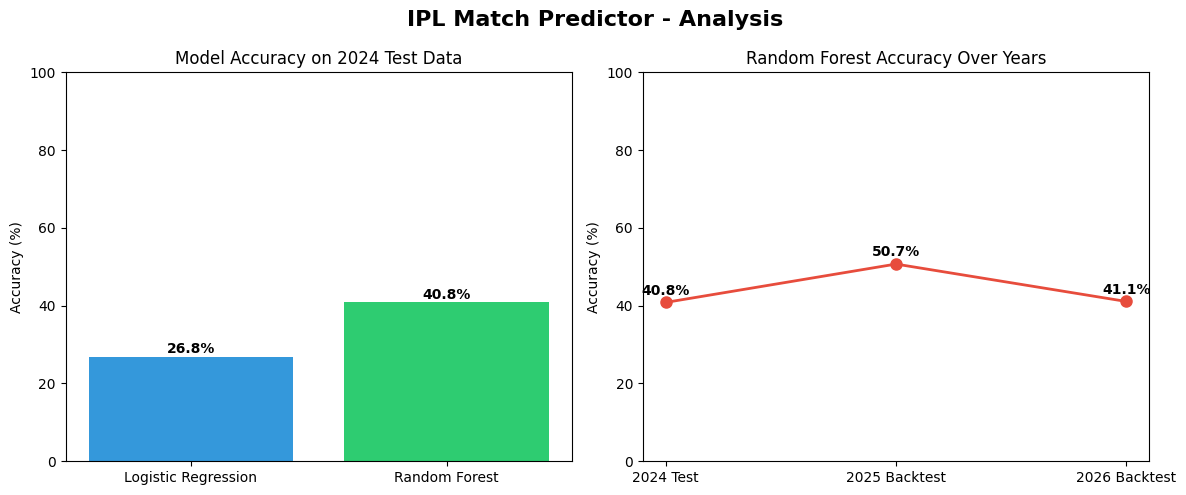

Charts saved to visuals/!


In [157]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('IPL Match Predictor - Analysis', fontsize=16, fontweight='bold')

# ============================
# Chart 1 - Model Accuracy Comparison
# ============================
models = ['Logistic Regression', 'Random Forest']
test_scores = [
    accuracy_score(y_test, lr_pred)*100,
    accuracy_score(y_test, rf_pred)*100
]

axes[0].bar(models, test_scores, color=['#3498db', '#2ecc71'])
axes[0].set_title('Model Accuracy on 2024 Test Data')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
for i, v in enumerate(test_scores):
    axes[0].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

# ============================
# Chart 2 - Backtesting Results
# ============================
years = ['2024 Test', '2025 Backtest', '2026 Backtest']
rf_scores = [
    accuracy_score(y_test, rf_pred)*100,
    accuracy_score(y_backtest_2025, rf_pred_2025)*100,
    accuracy_score(y_backtest_2026, rf_pred_2026)*100
]

axes[1].plot(years, rf_scores, marker='o', color='#e74c3c', linewidth=2, markersize=8)
axes[1].set_title('Random Forest Accuracy Over Years')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(rf_scores):
    axes[1].text(i, v+2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/ipl_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved to visuals/!")